## Model Development

In [1]:
# Import libraries 
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
import os, sys 

# System configuration 
sys.path.append(os.path.abspath(".."))

## Model Development: Approach

- Data Preparation
- Model Selection
- Model Training
- Model Validation: by Predictive Modeling
- Model Registration

Purpose of notebook:
- apply ml techniques to train and test models that are build and configured
- implement configured and built models from ml unility files
- fully training models pre-built datasets from data folder 
- end goal: register fully trained models for evaluating its performance in another notebook

## Data Preparation

In [2]:
# Import dependencies for data preparation
from scripts.data_collection import DataLoader
from scripts.data_manipulation import DataSplitter

In [3]:
# Instantiate the DataLoader()-object to load dataset
dataloader = DataLoader(folder=r"training\prepared_set")
dataset = dataloader.collect(filename="data_prepared_set_v1.csv")
dataset

,Ram_gb,Ssd,Hdd,Graphic_card_gb,Touchscreen,Core i3,Core i5,Core i7,Core i9,Ryzen 3,Ryzen 5,Ryzen 7,Ryzen 9,Weight,Casual,Gaming,ThinNlight,Price,Windows,Mac
0,4,512,1024,0,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Casual,1.0,0.0,0.0,34649,1.0,0.0
1,4,512,1024,0,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Casual,1.0,0.0,0.0,38999,1.0,0.0
2,4,512,1024,0,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Casual,1.0,0.0,0.0,39999,1.0,0.0
3,8,512,0,2,0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,Casual,1.0,0.0,0.0,69990,1.0,0.0
4,4,512,512,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Casual,1.0,0.0,0.0,26990,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
796,4,1024,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,Casual,1.0,0.0,0.0,135990,1.0,0.0
797,4,1024,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,Casual,1.0,0.0,0.0,144990,1.0,0.0
798,4,1024,0,4,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,Casual,1.0,0.0,0.0,149990,1.0,0.0
799,4,1024,0,4,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,Casual,1.0,0.0,0.0,142990,1.0,0.0


In [4]:
# Descriptive analysis: Understand the dataset distribution
dataset.info()
print(f"Categorical feature(before removal): Weight")

print(f"--"*1000)
# Remove the Weight feature
dataset = dataset.drop(columns=["Weight"], axis=1)
dataset.info()
print(f"Categorical feature (after removal): Weight")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 801 entries, 0 to 800
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Ram_gb           801 non-null    int64  
 1   Ssd              801 non-null    int64  
 2   Hdd              801 non-null    int64  
 3   Graphic_card_gb  801 non-null    int64  
 4   Touchscreen      801 non-null    int64  
 5   Core i3          801 non-null    float64
 6   Core i5          801 non-null    float64
 7   Core i7          801 non-null    float64
 8   Core i9          801 non-null    float64
 9   Ryzen 3          801 non-null    float64
 10  Ryzen 5          801 non-null    float64
 11  Ryzen 7          801 non-null    float64
 12  Ryzen 9          801 non-null    float64
 13  Weight           801 non-null    object 
 14  Casual           801 non-null    float64
 15  Gaming           801 non-null    float64
 16  ThinNlight       801 non-null    float64
 17  Price           

## Data Preparation

In [5]:
# Instantiate the DataSplitter()-object
datasplitter = DataSplitter(target_feature="Price")
training_set, testing_set = datasplitter.prepare(dataset=dataset, test_size=0.25)
datasplitter.provide_summary(dataset)

Training sets --------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [6]:
# Prepare the dataset 
xtrain, ytrain = training_set
xtest, ytest = testing_set

## Model Building & Training

In [7]:
# Import models from model script
from scripts.ml_utils.models import RegressionModel

Model 1: Linear Regression Model

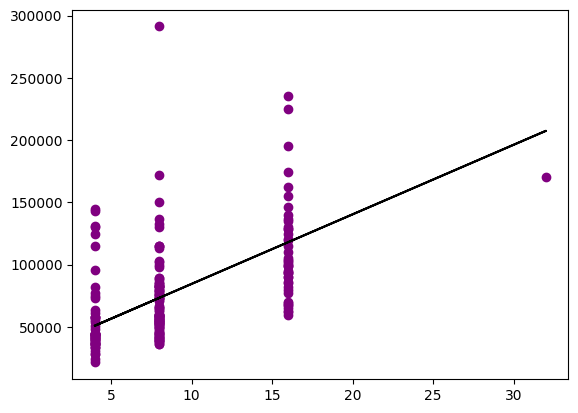

In [17]:
# Build a linear regression model 
regmodel = RegressionModel()
model1 = regmodel.select_model("linear regression model")

# Train the linear regression model 
model1.fit(xtrain[["Ram_gb"]], ytrain)

# Make prediction on price 
ypred = model1.predict(xtest[["Ram_gb"]])

# Create visualization 
plt.scatter(xtest[["Ram_gb"]], ytest, color="purple")
plt.plot(xtest[["Ram_gb"]], ypred, color="black")